# Faithfulness Experiments for KernelSHAP Insertion/Deletion Curves

This notebook reproduces the faithfulness experiments for the XAI-Vision project.

Faithfulness of KernelSHAP attributions are measured using insertion/deletion curves and the Area between Insertion and Deletion curves (AID).

Experiment 1: Effect of masking strategy (blurred / zeros / average / ones) on AID, across 3 images at different confidence levels.

Experiment 2: Effect of n_superpixels (10 / 20 / 30 / 40 / 50) on AID, using blurred baseline.

Images used: cat1 (74%), cat2 (65%), cat3 (37%)

Model: ResNet18 pretrained on ImageNet.

## Setup

In [15]:
%cd /content
!git clone https://github.com/BarbaraBugala/XAI-Vision.git
%cd XAI-Vision

/content
fatal: destination path 'XAI-Vision' already exists and is not an empty directory.
/content/XAI-Vision


In [2]:
!pip install captum scikit-image shapiq --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 87.9 MB/s eta 0:00:00


In [16]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/content/XAI-Vision/src")
sys.path.append("/content/XAI-Vision/explanations")

from framework import XAIPipeline
from faithfulness import run_faithfulness

# shared config across all experiments
images    = ["cat1.png", "cat2.png", "cat3.png"]
labels    = ["cat1 (74%)", "cat2 (65%)", "cat3 (37%)"]
colors    = ["#2196F3", "#FF9800", "#4CAF50"]
pipeline  = XAIPipeline()

## Experiment 1: Masking Strategy

Fixed: n_segments=50, n_samples=200.  
Varied: baseline type (blurred / zeros / average / ones).  

Here we investigate the effect of choice of masking strategies on faithfulness and its interaction with confidence levels.

In [19]:
masking_strategies = ["blurred", "zeros", "average", "ones"]
n_segments_fixed   = 50

exp1_results = {strategy: {} for strategy in masking_strategies}

for strategy in masking_strategies:
    print(f"\nmasking: {strategy}")
    for fname in images:
        print(f"  {fname}...", end=" ")
        outputs = pipeline.run_experiment(
            image_path=os.path.join("data", fname),
            method_name="kernel_shap",
            config={
                "n_segments":    n_segments_fixed,
                "baseline_type": strategy,
                "compactness":   10,
                "sigma":         1,
                "num_samples":   200,
                "save_file":     False,
                "insertion-deletion_score": False,
            }
        )
        result = run_faithfulness(
            model         = outputs["model"],
            input_tensor  = outputs["input_tensor"],
            class_idx     = outputs["class_idx"],
            attributions  = outputs["attributions"],
            segments      = outputs["segments"],
            baseline_type = strategy,
            aggregation   = "sum"
        )
        exp1_results[strategy][fname] = result
        print(f"AID = {result['aid']:.3f}")


masking: blurred
  cat1.png... Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


File: data/cat1.png | Pred: tabby (74.40%)
Calculating attributions via 'kernel_shap'...
AID = 0.850
  cat2.png... File: data/cat2.png | Pred: tabby (64.88%)
Calculating attributions via 'kernel_shap'...
AID = 0.823
  cat3.png... File: data/cat3.png | Pred: tabby (37.16%)
Calculating attributions via 'kernel_shap'...
AID = 0.664

masking: zeros
  cat1.png... File: data/cat1.png | Pred: tabby (74.40%)
Calculating attributions via 'kernel_shap'...
AID = 0.856
  cat2.png... File: data/cat2.png | Pred: tabby (64.88%)
Calculating attributions via 'kernel_shap'...
AID = 0.875
  cat3.png... File: data/cat3.png | Pred: tabby (37.16%)
Calculating attributions via 'kernel_shap'...
AID = 0.724

masking: average
  cat1.png... File: data/cat1.png | Pred: tabby (74.40%)
Calculating attributions via 'kernel_shap'...
AID = 0.865
  cat2.png... File: data/cat2.png | Pred: tabby (64.88%)
Calculating attributions via 'kernel_shap'...
AID = 0.668
  cat3.png... File: data/cat3.png | Pred: tabby (37.16%)
Cal

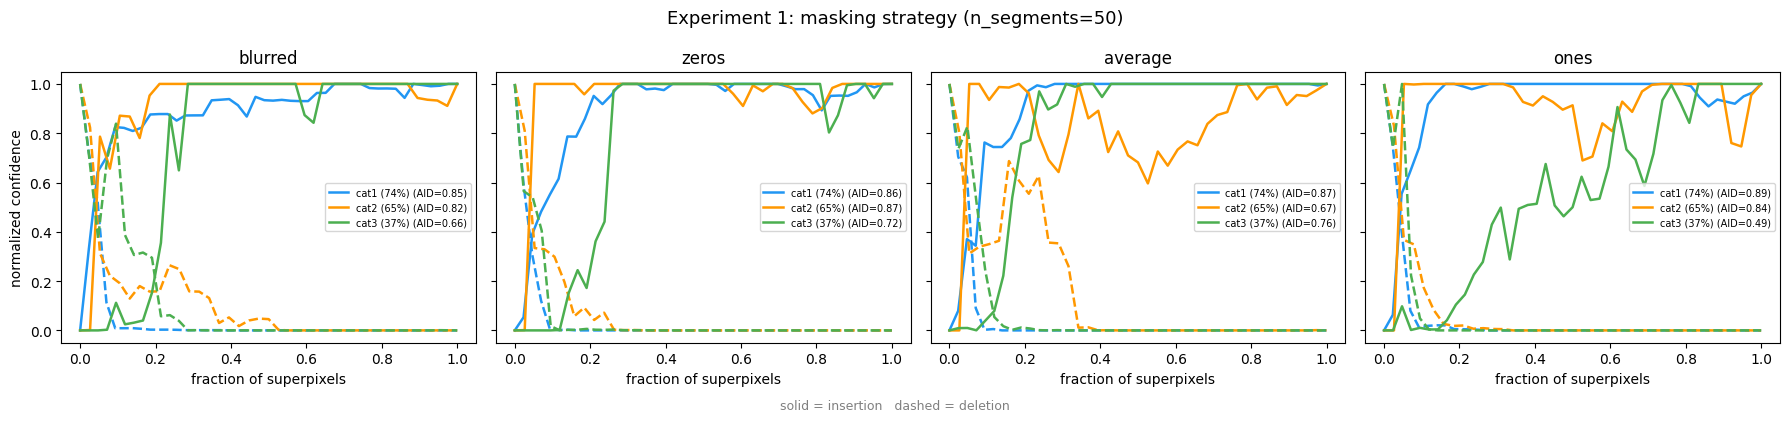

In [25]:
#plot insertion/deletion curves

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle("Experiment 1: masking strategy (n_segments=50)", fontsize=13)

for ax, strategy in zip(axes, masking_strategies):
    for fname, label, color in zip(images, labels, colors):
        r   = exp1_results[strategy][fname]
        x   = np.linspace(0, 1, len(r["insertion_curve"]))
        aid = r["aid"]
        ax.plot(x, r["insertion_curve"], color=color, linewidth=1.8,
                label=f"{label} (AID={aid:.2f})")
        ax.plot(x, r["deletion_curve"],  color=color, linewidth=1.8,
                linestyle="--")
    ax.set_title(strategy)
    ax.set_xlabel("fraction of superpixels")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)

axes[0].set_ylabel("normalized confidence")
fig.text(0.5, -0.02, "solid = insertion   dashed = deletion",
         ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("xai_results/exp1_masking_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

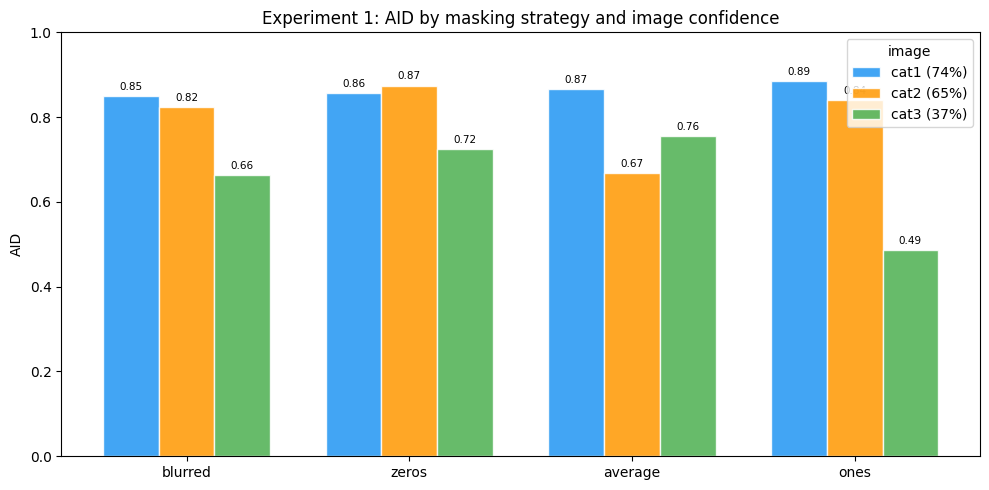

saved


In [21]:
# AID summary bar chart

aid_values_exp1 = np.array([
    [exp1_results[s][f]["aid"] for s in masking_strategies]
    for f in images
])

x     = np.arange(len(masking_strategies))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, color) in enumerate(zip(labels, colors)):
    ax.bar(x + i * width, aid_values_exp1[i], width,
           label=label, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(masking_strategies)
ax.set_ylabel("AID")
ax.set_ylim(0, 1.0)
ax.set_title("Experiment 1: AID by masking strategy and image confidence")
ax.legend(title="image")

for i in range(len(labels)):
    for j in range(len(masking_strategies)):
        ax.text(j + i * width, aid_values_exp1[i, j] + 0.01,
                f"{aid_values_exp1[i, j]:.2f}",
                ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig("xai_results/exp1_aid_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

##Experiment 2: n_superpixels Robustness

Fixed: baseline=blurred, n_samples=200.  
Varied: n_superpixels (10 / 20 / 30 / 40 / 50)

Here we investigate if AID is stable across different numbers of segments and its interaction with confidence levels



In [22]:
superpixel_values = [10, 20, 30, 40, 50]
strategy_fixed    = "blurred"

exp2_results = {n: {} for n in superpixel_values}

for n_seg in superpixel_values:
    print(f"\nn_segments: {n_seg}")
    for fname in images:
        print(f"  {fname}...", end=" ")
        outputs = pipeline.run_experiment(
            image_path=os.path.join("data", fname),
            method_name="kernel_shap",
            config={
                "n_segments":    n_seg,
                "baseline_type": strategy_fixed,
                "compactness":   10,
                "sigma":         1,
                "num_samples":   200,
                "save_file":     False,
                "insertion-deletion_score": False,
            }
        )
        result = run_faithfulness(
            model         = outputs["model"],
            input_tensor  = outputs["input_tensor"],
            class_idx     = outputs["class_idx"],
            attributions  = outputs["attributions"],
            segments      = outputs["segments"],
            baseline_type = strategy_fixed,
            aggregation   = "sum"
        )
        exp2_results[n_seg][fname] = result
        print(f"AID = {result['aid']:.3f}")


n_segments: 10
  cat1.png... File: data/cat1.png | Pred: tabby (74.40%)
Calculating attributions via 'kernel_shap'...
AID = 0.711
  cat2.png... File: data/cat2.png | Pred: tabby (64.88%)
Calculating attributions via 'kernel_shap'...
AID = 0.569
  cat3.png... File: data/cat3.png | Pred: tabby (37.16%)
Calculating attributions via 'kernel_shap'...
AID = 0.723

n_segments: 20
  cat1.png... File: data/cat1.png | Pred: tabby (74.40%)
Calculating attributions via 'kernel_shap'...
AID = 0.782
  cat2.png... File: data/cat2.png | Pred: tabby (64.88%)
Calculating attributions via 'kernel_shap'...
AID = 0.783
  cat3.png... File: data/cat3.png | Pred: tabby (37.16%)
Calculating attributions via 'kernel_shap'...
AID = 0.538

n_segments: 30
  cat1.png... File: data/cat1.png | Pred: tabby (74.40%)
Calculating attributions via 'kernel_shap'...
AID = 0.865
  cat2.png... File: data/cat2.png | Pred: tabby (64.88%)
Calculating attributions via 'kernel_shap'...
AID = 0.728
  cat3.png... File: data/cat3.pn

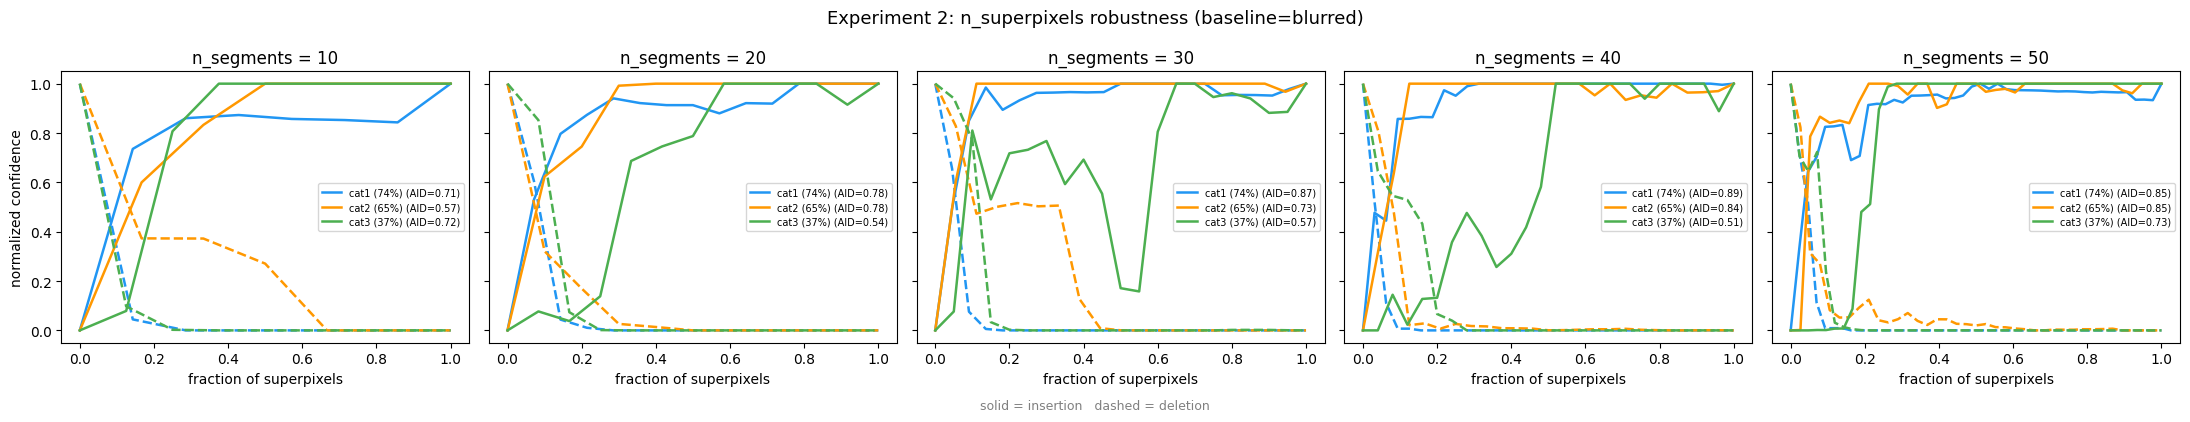

In [23]:
# plot insertion deletion curves

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
fig.suptitle("Experiment 2: n_superpixels robustness (baseline=blurred)", fontsize=13)

for ax, n_seg in zip(axes, superpixel_values):
    for fname, label, color in zip(images, labels, colors):
        r   = exp2_results[n_seg][fname]
        x   = np.linspace(0, 1, len(r["insertion_curve"]))
        aid = r["aid"]
        ax.plot(x, r["insertion_curve"], color=color, linewidth=1.8,
                label=f"{label} (AID={aid:.2f})")
        ax.plot(x, r["deletion_curve"],  color=color, linewidth=1.8,
                linestyle="--")
    ax.set_title(f"n_segments = {n_seg}")
    ax.set_xlabel("fraction of superpixels")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)

axes[0].set_ylabel("normalized confidence")
fig.text(0.5, -0.02, "solid = insertion   dashed = deletion",
         ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("xai_results/exp2_superpixels_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

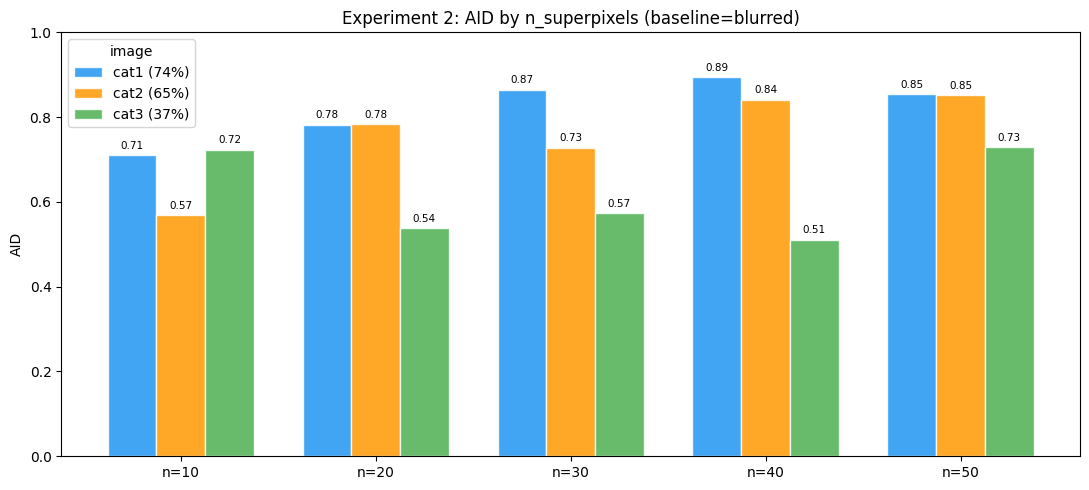

In [24]:
# AID summary bar chart

aid_values_exp2 = np.array([
    [exp2_results[n][f]["aid"] for n in superpixel_values]
    for f in images
])

x     = np.arange(len(superpixel_values))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (label, color) in enumerate(zip(labels, colors)):
    ax.bar(x + i * width, aid_values_exp2[i], width,
           label=label, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels([f"n={n}" for n in superpixel_values])
ax.set_ylabel("AID")
ax.set_ylim(0, 1.0)
ax.set_title("Experiment 2: AID by n_superpixels (baseline=blurred)")
ax.legend(title="image")

for i in range(len(labels)):
    for j in range(len(superpixel_values)):
        ax.text(j + i * width, aid_values_exp2[i, j] + 0.01,
                f"{aid_values_exp2[i, j]:.2f}",
                ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig("xai_results/exp2_aid_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()
